# 🛒 Shopper Spectrum — Analysis Notebook

Customer Segmentation (RFM + KMeans) and Product Recommendations (item-based collaborative filtering) for e-commerce.

This notebook walks through the same pipeline implemented in `src/`. Run it from the project root with the project virtual environment selected as the kernel.

In [4]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

from src.data_loader import get_dataset
from src.preprocessing import clean_transactions, build_rfm

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Load & explore the data



In [5]:
raw = get_dataset()
print(raw.shape)
raw.head()

[data] Using real dataset: f:\Shopper Spectrum\data\online_retail.csv
(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [6]:
raw.info()
print('\nMissing values:\n', raw.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB

Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## 2. Data preprocessing

* Drop missing `CustomerID`
* Exclude cancelled invoices (`InvoiceNo` starting with `C`)
* Remove non-positive quantity / price

In [7]:
df = clean_transactions(raw)
print(df.attrs['clean_report'])
df.head()

{'raw_rows': 541909, 'after_drop_missing_customer': 406829, 'after_drop_cancelled': 397924, 'after_drop_nonpositive': 397884, 'after_drop_dupes_nulls': 392692}


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. Exploratory Data Analysis

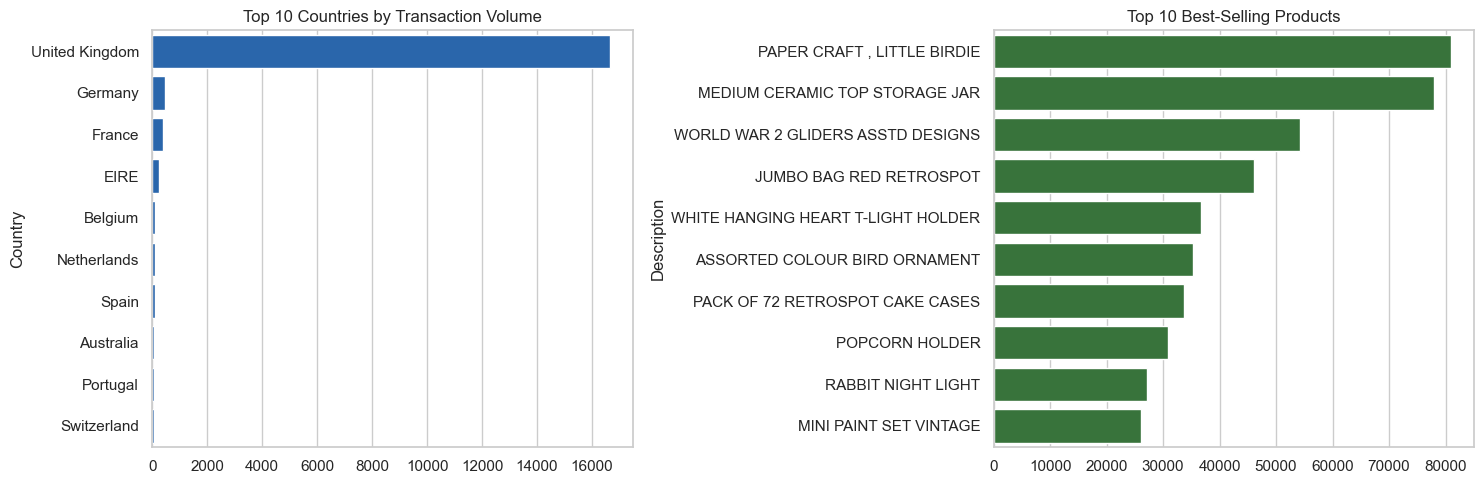

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
top_countries = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, color='#1565c0', ax=axes[0])
axes[0].set_title('Top 10 Countries by Transaction Volume')

top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, color='#2e7d32', ax=axes[1])
axes[1].set_title('Top 10 Best-Selling Products')
plt.tight_layout(); plt.show()

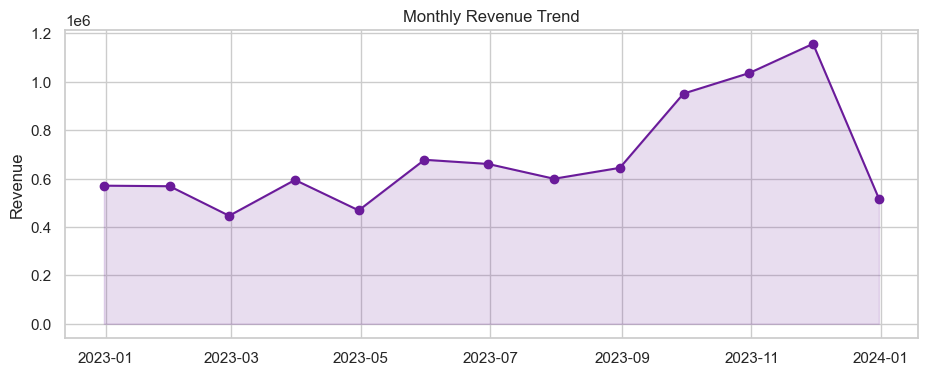

In [9]:
monthly = df.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()
plt.figure(figsize=(11, 4))
plt.plot(monthly.index, monthly.values, marker='o', color='#6a1b9a')
plt.fill_between(monthly.index, monthly.values, alpha=0.15, color='#6a1b9a')
plt.title('Monthly Revenue Trend'); plt.ylabel('Revenue'); plt.show()

## 4. RFM feature engineering

In [10]:
rfm = build_rfm(df)
print('Snapshot date:', rfm.attrs['snapshot_date'])
rfm.describe()

Snapshot date: 2023-12-10 12:50:00


,CustomerID,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00","4,338.00"
mean,"15,300.41",92.54,4.27,"2,048.69"
std,"1,721.81",100.01,7.70,"8,985.23"
min,"12,346.00",1.00,1.00,3.75
25%,"13,813.25",18.00,1.00,306.48
50%,"15,299.50",51.00,2.00,668.57
75%,"16,778.75",142.00,5.00,"1,660.60"
max,"18,287.00",374.00,209.00,"280,206.02"


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, c in zip(axes, ['Recency','Frequency','Monetary'], ['#c62828','#1565c0','#2e7d32']):
    data = rfm[col]
    if col == 'Monetary': data = data.clip(upper=data.quantile(0.99))
    sns.histplot(data, bins=40, color=c, ax=ax); ax.set_title(f'{col} Distribution')
plt.tight_layout(); plt.show()

## 5. Clustering — choosing k (elbow + silhouette)

In [ ]:
rfm_log = rfm[['Recency','Frequency','Monetary']].copy()
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])
X = StandardScaler().fit_transform(rfm_log)

ks = range(2, 11); inertias=[]; sils=[]
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_); sils.append(silhouette_score(X, km.labels_))

fig, (a1,a2) = plt.subplots(1,2, figsize=(13,4))
a1.plot(list(ks), inertias, 'o-', color='#1565c0'); a1.set_title('Elbow (Inertia)'); a1.set_xlabel('k')
a2.plot(list(ks), sils, 'o-', color='#2e7d32'); a2.set_title('Silhouette Score'); a2.set_xlabel('k')
plt.tight_layout(); plt.show()

## 6. Fit KMeans and label segments

In [ ]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(X)
centers = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

# Rank clusters by RFM desirability and map to the four business segments
r = (centers['Recency'].max()-centers['Recency'])/(centers['Recency'].max()-centers['Recency'].min()+1e-9)
f = (centers['Frequency']-centers['Frequency'].min())/(centers['Frequency'].max()-centers['Frequency'].min()+1e-9)
m = (centers['Monetary']-centers['Monetary'].min())/(centers['Monetary'].max()-centers['Monetary'].min()+1e-9)
score = 0.3*r + 0.3*f + 0.4*m
order = score.sort_values(ascending=False).index.tolist()
names = ['High-Value','Regular','Occasional','At-Risk']
mapping = {c: names[i] for i, c in enumerate(order)}
rfm['Segment'] = rfm['Cluster'].map(mapping)

rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)

In [ ]:
palette = {'High-Value':'#2e7d32','Regular':'#1565c0','Occasional':'#f9a825','At-Risk':'#c62828'}
plt.figure(figsize=(8,5.5))
for seg,c in palette.items():
    sub = rfm[rfm['Segment']==seg]
    plt.scatter(sub['Recency'], sub['Monetary'].clip(upper=rfm['Monetary'].quantile(0.98)), s=16, alpha=0.6, label=seg, color=c)
plt.xlabel('Recency (days)'); plt.ylabel('Monetary'); plt.title('Customer Segments'); plt.legend(); plt.show()

## 7. Product recommendation — item-based collaborative filtering

In [ ]:
pivot = df.pivot_table(index='CustomerID', columns='Description', values='Quantity', aggfunc='sum', fill_value=0)
sim = pd.DataFrame(cosine_similarity(pivot.T.values), index=pivot.columns, columns=pivot.columns)

def recommend(product, n=5):
    if product not in sim.index: return []
    return sim[product].drop(product).sort_values(ascending=False).head(n)

example = sim.index[0]
print(f'Top 5 similar to: {example}')
recommend(example)

## 8. Persist artifacts

The production pipeline (`python -m src.train`) saves the scaler, KMeans model, cluster labels, and similarity matrix to `models/` for the Streamlit app. Run it to (re)generate everything, then launch `streamlit run app.py`.